# Quadcopter Kinematic Lyapunov Path Following

In this notebook, we present a symbolic derivation of a Lyapunov-based kinematic control law for a quadcopter to track a 3D trajectory (a circle at constant altitude), and simulate it using the MuJoCo engine wrapper.

In [1]:
import sys
from pathlib import Path
 
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
 
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Math, display, Video, Image
 
from src.simulation.video_sim import VideoSim
from src.utils.config import load_config
from src.utils.plotting import set_style, FigureManager
from src.utils.animations import quadcopter_topdown
from src.symbolic.quadcopter_kinematic_lyapunov import derive_lyapunov
 
set_style()   # apply once at the top

This is a great addition to your notebook. Your baseline notes provide the rigorous rigid-body dynamics ($SE(3)$), but since your Python simulation and Lyapunov derivation rely on a simplified, fully actuated kinematic model, the best approach is to present **both** to show how they connect.

Here is a formatted Markdown section you can copy and paste directly into your Jupyter Notebook. It bridges your baseline notes with your controller implementation by defining both the full dynamic state-space and the reduced kinematic state-space.

---

### State-Space Representation

To formalize the vehicle's motion and bridge the gap between fundamental rigid-body dynamics and our control design, we can frame the quadcopter's equations of motion in a standard state-space formulation, $\dot{\mathbf{x}} = f(\mathbf{x}, \mathbf{u})$.

Depending on the control architecture's level of abstraction, we utilize either a full dynamic state-space model or a reduced kinematic state-space model.

#### 1. Full Dynamic State-Space Model ($SE(3)$)

Using the rigid-body dynamics detailed in the theoretical notes, the full state of the quadcopter encompasses its position, orientation, linear velocity, and angular velocity. Let the state vector be defined on the manifold $SE(3) \times \mathbb{R}^3 \times \mathbb{R}^3$:


$$\mathbf{x} = (p, R, \nu, \omega)$$

The control input vector $\mathbf{u} \in \mathbb{R}^4$ consists of the total thrust $T$ (derived from the force vector $f$) and the three control torques $\tau$:


$$\mathbf{u} = \begin{bmatrix} T \\ \tau \end{bmatrix} = \begin{bmatrix} \sum_{i=1}^{4} k \Omega_{i}^{2} \\ lk (\Omega_1^2 - \Omega_2^2 - \Omega_3^2 + \Omega_4^2) \\ lk (\Omega_1^2 + \Omega_2^2 - \Omega_3^2 + \Omega_4^2) \\ b (\Omega_1^2 - \Omega_2^2 + \Omega_3^2 - \Omega_4^2) \end{bmatrix}$$

The nonlinear state-space equations are given by:


$$\dot{p} = R\nu$$

$$\dot{R} = R S(\omega)$$

$$\dot{\nu} = -S(\omega)\nu + R^\top \bar{g} - \frac{1}{m}D_\nu(\nu)\nu + \frac{1}{m}\begin{bmatrix} 0 \\ 0 \\ T \end{bmatrix}$$

$$\dot{\omega} = -J^{-1} S(\omega) J \omega - J^{-1} D_\omega(\omega)\omega + J^{-1} \tau$$

*Note:* This model is underactuated (4 inputs for 6 degrees of freedom). As is standard in multirotor control architectures, this is handled via time-scale separation, utilizing a high-bandwidth inner-loop for attitude/dynamics and an outer-loop for position/kinematics.

#### 2. Reduced Kinematic State-Space Model

For the Lyapunov-based path-following controller derived in this notebook, we operate on the reduced-order, outer-loop kinematic model. By assuming the inner-loop attitude controller perfectly tracks our velocity and yaw commands, we can abstract away the forces and torques.

Here, the state vector $\mathbf{x} \in \mathbb{R}^4$ is simply the 3D position and the yaw angle:


$$\mathbf{x} = \begin{bmatrix} x \\ y \\ z \\ \psi \end{bmatrix}$$

The control input $\mathbf{u} \in \mathbb{R}^4$ consists of the commanded linear velocities and yaw rate:


$$\mathbf{u} = \begin{bmatrix} v_x \\ v_y \\ v_z \\ \omega_\psi \end{bmatrix}$$

The resulting kinematic state-space model is fully actuated and linear:


$$\dot{\mathbf{x}} = \mathbf{u} \implies \begin{bmatrix} \dot{x} \\ \dot{y} \\ \dot{z} \\ \dot{\psi} \end{bmatrix} = \begin{bmatrix} v_x \\ v_y \\ v_z \\ \omega_\psi \end{bmatrix}$$

This formulation serves as the direct foundation for the error dynamics $\dot{\mathbf{e}}$ and the subsequent Lyapunov stability proof simulated above.

In [2]:
res = derive_lyapunov()

display(Math(r"V = " + sp.latex(res['V'])))
display(Math(r"\dot{V} = " + sp.latex(res['V_dot'])))
display(Math(r"v_x = " + sp.latex(res['law_vx'])))
display(Math(r"v_y = " + sp.latex(res['law_vy'])))
display(Math(r"v_z = " + sp.latex(res['law_vz'])))
display(Math(r"\omega_\psi = " + sp.latex(res['law_wpsi'])))
display(Math(r"\dot{V}_{sub} = " + sp.latex(res['V_dot_sub']) + r" \le 0"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### LaSalle's Invariance Principle and Global Asymptotic Stability

To prove Global Asymptotic Stability (GAS) using Lyapunov theory and LaSalle's invariance principle, we look at the derivative of the Lyapunov function $\dot{V}$. 

The question is **where does $\dot{V} = 0$?**

From the derived $\dot{V}_{sub}$:
$$ \dot{V} = - k_x e_x^2 - k_y e_y^2 - k_z e_z^2 - k_\psi e_\psi^2 $$

Assuming strictly positive control gains ($k_x, k_y, k_z, k_\psi > 0$), we have $\dot{V} \le 0$ globally.
The set $E$ where $\dot{V} = 0$ is given by:

$$ E = \left\{ (e_x, e_y, e_z, e_\psi) \in \mathbb{R}^4 \mid \dot{V} = 0 \right\} = \left\{ (0, 0, 0, 0) \right\} $$

Because the error dynamics are exactly autonomous ($\dot{e}_x = -k_x e_x$, etc.), we can apply **LaSalle's Invariance Principle**:
1. $\dot{V} \le 0$ everywhere (the error states are bounded).
2. The set where $\dot{V} = 0$ contains only the origin of the error space $\mathbf{e} = 0$.
3. The largest invariant set $M$ contained in $E$ is trivially the origin.

Therefore, by LaSalle's principle, all state trajectories must converge to the largest invariant set $M$ within $E$ as $t \to \infty$. This proves that $e(t) \to 0$ globally, ensuring **Global Asymptotic Stability** of the path following scheme.

## Simulation implementation

In [3]:
config_path = str(ROOT / "config/quadcopter_lyapunov_circle.yaml")
cfg = load_config(config_path)
 
fm = FigureManager(cfg, base_dir=ROOT)
# figures will be written to  <ROOT>/<cfg['figures_dir']>/

class QuadcopterLyapunovSim(VideoSim):
    def __init__(self, config):
        super().__init__(config)
        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model needs a free root joint.")

        # Initialize away from the trajectory to show convergence
        self.start_x = 0.0
        self.start_y = 0.0
        self.start_z = 0.5
        self.data.qpos[:7] = np.array([self.start_x, self.start_y, self.start_z, 1.0, 0.0, 0.0, 0.0])
        self.data.qvel[:6] = 0.0
        
        # Internal kinematic tracking
        self._x = self.start_x
        self._y = self.start_y
        self._z = self.start_z
        self._yaw = 0.0

        # Controller gains
        ctrl_cfg = self.cfg.get('controller', {})
        self.kx = ctrl_cfg.get('kx', 1.0)
        self.ky = ctrl_cfg.get('ky', 1.0)
        self.kz = ctrl_cfg.get('kz', 1.0)
        self.kpsi = ctrl_cfg.get('kpsi', 1.0)

        # Trajectory parameters
        traj_cfg = self.cfg.get('trajectory', {})
        self.R = traj_cfg.get('radius', 3.0)
        self.omega = traj_cfg.get('omega', 0.5)
        self.z_d = traj_cfg.get('z_height', 3.0)
        
        # Camera setup
        cam_cfg = self.cfg.get('camera', {})
        self._cam_lookat   = np.array(cam_cfg.get('lookat',    [0.0, 0.0, 2.0]))
        self._cam_distance = float(cam_cfg.get('distance',  10.0))
        self._cam_elevation= float(cam_cfg.get('elevation', -30.0))
        self._cam_azimuth  = float(cam_cfg.get('azimuth',   45.0))
        
    def _capture_frame(self):
        self._camera.lookat[:] = self._cam_lookat
        self._camera.distance  = self._cam_distance
        self._camera.elevation = self._cam_elevation
        self._camera.azimuth   = self._cam_azimuth
        self._renderer.update_scene(self.data, camera=self._camera)
        self._frames.append(self._renderer.render())
        
    def _loop_step(self, t: float, step: int):
        dt = self.model.opt.timestep
        
        # 1. Reference trajectory
        xd = self.R * np.cos(self.omega * t)
        yd = self.R * np.sin(self.omega * t)
        zd = self.z_d
        psid = self.omega * t + np.pi/2.0
        
        vxd = -self.R * self.omega * np.sin(self.omega * t)
        vyd =  self.R * self.omega * np.cos(self.omega * t)
        vzd = 0.0
        psid_dot = self.omega
        
        # 2. Tracking errors
        ex = self._x - xd
        ey = self._y - yd
        ez = self._z - zd
        
        # Wrap yaw error to [-pi, pi]
        epsi = self._yaw - psid
        epsi = (epsi + np.pi) % (2 * np.pi) - np.pi
        
        # 3. Control Laws (from Lyapunov derivation)
        vx = vxd - self.kx * ex
        vy = vyd - self.ky * ey
        vz = vzd - self.kz * ez
        wpsi = psid_dot - self.kpsi * epsi
        
        # 4. Update kinematic state
        self._x += vx * dt
        self._y += vy * dt
        self._z += vz * dt
        self._yaw += wpsi * dt
        self._yaw = (self._yaw + np.pi) % (2 * np.pi) - np.pi
        
        # 5. Write to MuJoCo state
        self.data.qpos[0] = self._x
        self.data.qpos[1] = self._y
        self.data.qpos[2] = self._z
        
        qw = np.cos(self._yaw / 2.0)
        qz = np.sin(self._yaw / 2.0)
        self.data.qpos[3:7] = [qw, 0.0, 0.0, qz]
        
        self.data.qvel[0] = vx
        self.data.qvel[1] = vy
        self.data.qvel[2] = vz
        self.data.qvel[3:6] = 0.0
        
        # Update camera lookat
        self._cam_lookat[:] = [self._x, self._y, self._z]
        
        # Log
        self.logger.log({
            "t": t,
            "x": float(self._x),
            "y": float(self._y),
            "z": float(self._z),
            "yaw": float(self._yaw),
            "xd": float(xd),
            "yd": float(yd),
            "zd": float(zd),
            "psid": float(psid),
            "ex": float(ex),
            "ey": float(ey),
            "ez": float(ez),
            "epsi": float(epsi),
        })
        
sim = QuadcopterLyapunovSim(config_path)
sim.run()
df = sim.to_dataframe()
df.tail()

Simulation: 100%|██████████| 10000/10000 [00:38<00:00, 260.08step/s]


Video saved → /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/videos/quadcopter_lyapunov_circle.mp4


,t,x,y,z,yaw,xd,yd,zd,psid,ex,ey,ez,epsi
9995,19.990,-2.524390,-1.622054,3.0,-0.999574,-2.525343,-1.619457,3.0,11.565796,-0.000667,-0.000072,-5.101522e-09,-3.205386e-09
9996,19.992,-2.522766,-1.624577,3.0,-0.998574,-2.523723,-1.621981,3.0,11.566796,-0.000667,-0.000072,-5.091319e-09,-3.198974e-09
9997,19.994,-2.521141,-1.627099,3.0,-0.997574,-2.522099,-1.624504,3.0,11.567796,-0.000667,-0.000073,-5.081137e-09,-3.192575e-09
9998,19.996,-2.519512,-1.629619,3.0,-0.996574,-2.520474,-1.627026,3.0,11.568796,-0.000667,-0.000074,-5.070975e-09,-3.186191e-09
9999,19.998,-2.517881,-1.632138,3.0,-0.995574,-2.518845,-1.629545,3.0,11.569796,-0.000667,-0.000074,-5.060833e-09,-3.179819e-09


In [4]:
from IPython.display import Video, Image, display

video_path = Path(load_config(config_path)['video_path'])
if not video_path.is_absolute():
    video_path = ROOT / video_path

if video_path.exists():
    display(Video(str(video_path), embed=True))
else:
    frames_dir = video_path.parent / (video_path.stem + '_frames')
    if frames_dir.exists():
        pngs = sorted(frames_dir.glob('*.png'))
        if pngs:
            display(Image(str(pngs[-1])))
            print(f"MP4 not available. Showing last frame from {frames_dir}")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/errors.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/errors.png


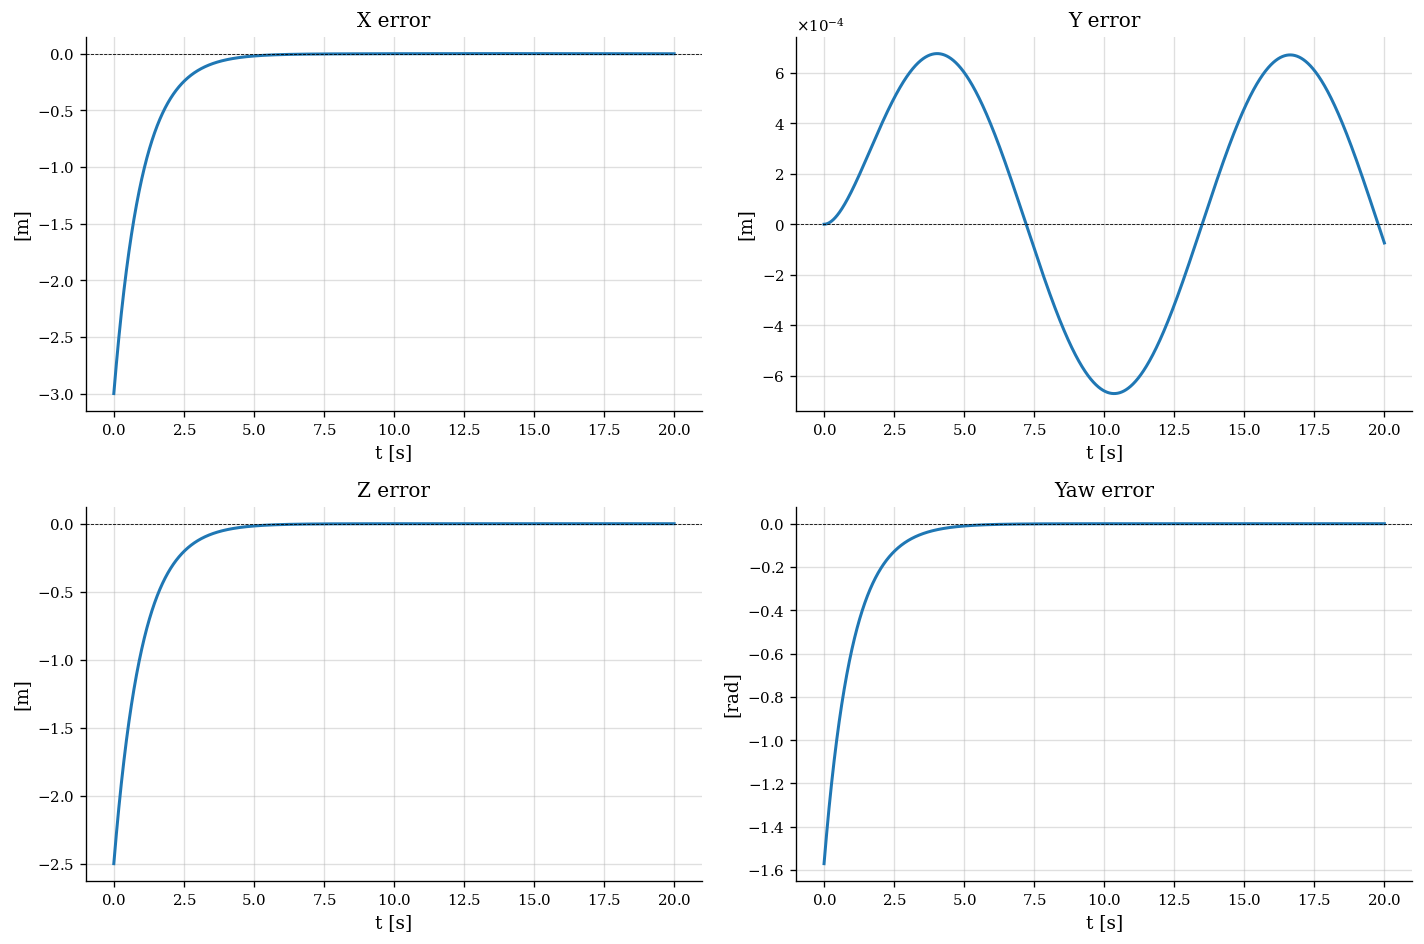

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/errors.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/errors.png')]

In [5]:
# fig, axs = plt.subplots(2, 2, figsize=(12, 8))
# axs[0,0].plot(df['t'], df['ex'], label='e_x')
# axs[0,0].set_title('X Error')
# axs[0,0].grid()

# axs[0,1].plot(df['t'], df['ey'], label='e_y')
# axs[0,1].set_title('Y Error')
# axs[0,1].grid()

# axs[1,0].plot(df['t'], df['ez'], label='e_z')
# axs[1,0].set_title('Z Error')
# axs[1,0].grid()

# axs[1,1].plot(df['t'], df['epsi'], label='e_psi')
# axs[1,1].set_title('Yaw Error')
# axs[1,1].grid()

# plt.tight_layout()
# plt.show()

fig_err = FigureManager.error_subplots(
    df,
    error_cols=["ex", "ey", "ez", "epsi"],
    labels=["X error", "Y error", "Z error", "Yaw error"],
    units=["m", "m", "m", "rad"],
)
fm.save_and_show(fig_err, "errors")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/lyapunov_levelsets.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/lyapunov_levelsets.png


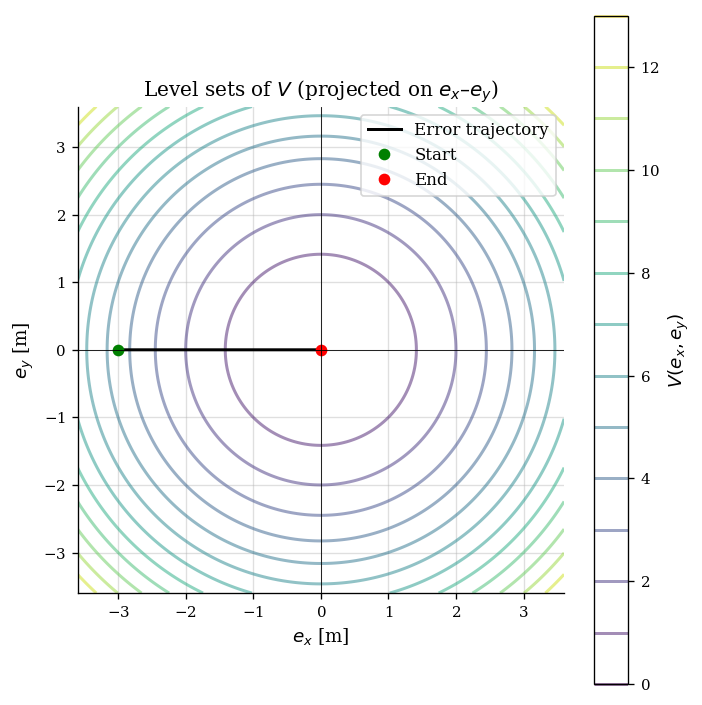

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/lyapunov_levelsets.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/lyapunov_levelsets.png')]

In [6]:
# fig, ax = plt.subplots(figsize=(6, 6))

# # Create a grid for the level sets
# e_x_vals = np.linspace(-4, 4, 100)
# e_y_vals = np.linspace(-4, 4, 100)
# E_X, E_Y = np.meshgrid(e_x_vals, e_y_vals)
# V_xy = 0.5 * (E_X**2 + E_Y**2)

# # Plot contours
# cp = ax.contour(E_X, E_Y, V_xy, levels=15, cmap='viridis', alpha=0.5)
# plt.colorbar(cp, ax=ax, label=r'$V(e_x, e_y)$')

# # Plot the trajectory
# ax.plot(df['ex'], df['ey'], 'k-', linewidth=2, label='Error Trajectory')
# ax.plot(df['ex'].iloc[0], df['ey'].iloc[0], 'go', label='Start')
# ax.plot(df['ex'].iloc[-1], df['ey'].iloc[-1], 'ro', label='End')

# ax.set_title('Level Sets of $V$ (projected on $e_x-e_y$ plane)')
# ax.set_xlabel(r'$e_x$ [m]')
# ax.set_ylabel(r'$e_y$ [m]')
# ax.grid(True)
# ax.axhline(0, color='black', linewidth=0.5)
# ax.axvline(0, color='black', linewidth=0.5)
# ax.legend()
# plt.axis('equal')
# plt.show()

fig_lyap = FigureManager.lyapunov_levelsets(df)
fm.save_and_show(fig_lyap, "lyapunov_levelsets")

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/path_3d.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/path_3d.png


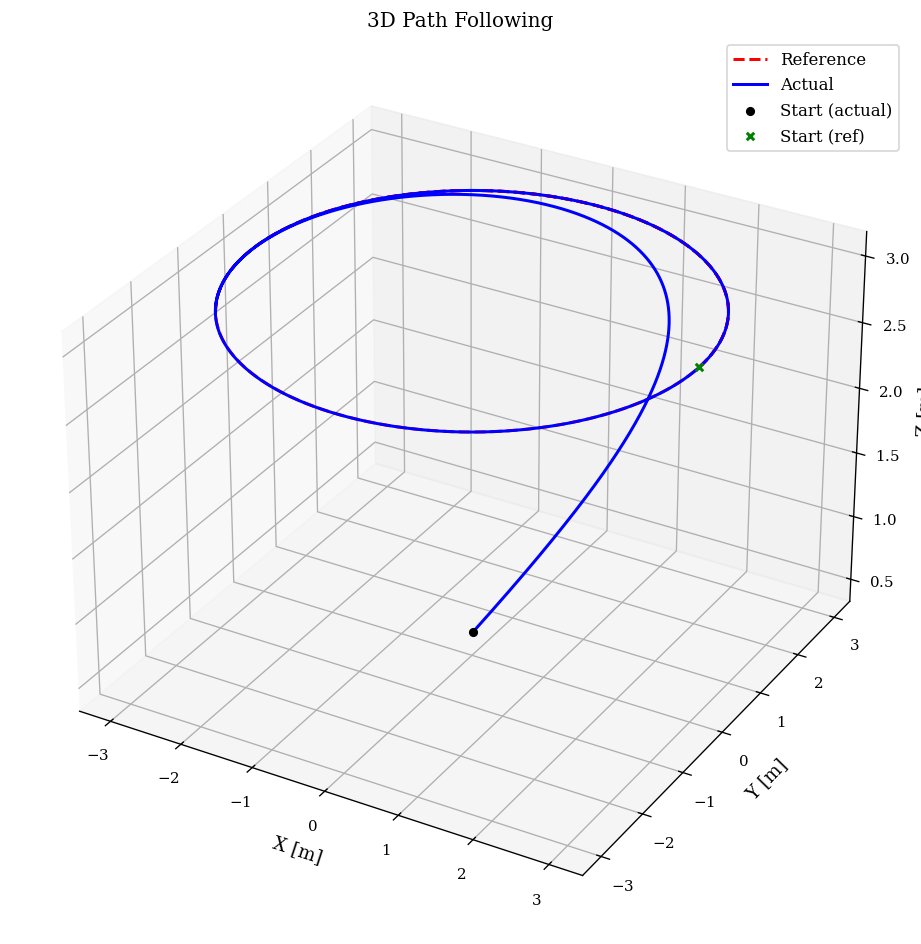

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/path_3d.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_lyapunov_circle/path_3d.png')]

In [7]:
# fig = plt.figure(figsize=(8,8))
# ax = fig.add_subplot(111, projection='3d')

# ax.plot(df['xd'], df['yd'], df['zd'], 'r--', label='Reference')
# ax.plot(df['x'], df['y'], df['z'], 'b-', label='Actual quadcopter')

# ax.scatter([df['x'].iloc[0]], [df['y'].iloc[0]], [df['z'].iloc[0]], color='black', marker='o', label='Start Actual')
# ax.scatter([df['xd'].iloc[0]], [df['yd'].iloc[0]], [df['zd'].iloc[0]], color='green', marker='x', label='Start Ref')

# ax.set_title('3D Path Following')
# ax.set_xlabel('X [m]')
# ax.set_ylabel('Y [m]')
# ax.set_zlabel('Z [m]')
# ax.legend()
# plt.show()

fig_3d = FigureManager.path_3d(df)
fm.save_and_show(fig_3d, "path_3d")

In [9]:
# # Animation of virtual vs actual
# fig, ax = plt.subplots(figsize=(8, 8))
# ax.set_xlim(-5, 5)
# ax.set_ylim(-5, 5)
# ax.set_xlabel('X [m]')
# ax.set_ylabel('Y [m]')
# ax.set_title('Quadcopter Top-Down View')
# ax.grid(True)
# ax.set_aspect('equal', adjustable='box')

# actual_traj, = ax.plot([], [], 'b-', alpha=0.5, label='Actual Traj')
# ref_traj,    = ax.plot([], [], 'r--', alpha=0.5, label='Ref Traj')

# # Drone representations (a cross + heading indicator)
# actual_path, = ax.plot([], [], 'bo', markersize=6)
# ref_path,    = ax.plot([], [], 'rx', markersize=6)
# actual_head, = ax.plot([], [], 'b-', linewidth=2)
# ref_head,    = ax.plot([], [], 'r-', linewidth=2)

# ax.legend()

# def init():
#     actual_traj.set_data([], [])
#     ref_traj.set_data([], [])
#     actual_path.set_data([], [])
#     ref_path.set_data([], [])
#     actual_head.set_data([], [])
#     ref_head.set_data([], [])
#     return actual_traj, ref_traj, actual_path, ref_path, actual_head, ref_head

# # Decimate data for animation to keep it smooth
# step = 50
# df_anim = df.iloc[::step].reset_index(drop=True)
# L = 0.5  # line length for plotting heading

# def update(frame):
#     data = df_anim.iloc[:frame+1]
#     current = df_anim.iloc[frame]
    
#     actual_traj.set_data(data['x'], data['y'])
#     ref_traj.set_data(data['xd'], data['yd'])
    
#     actual_path.set_data([current['x']], [current['y']])
#     ref_path.set_data([current['xd']], [current['yd']])
    
#     actual_head.set_data([current['x'], current['x'] + L*np.cos(current['yaw'])],
#                          [current['y'], current['y'] + L*np.sin(current['yaw'])])
    
#     ref_head.set_data([current['xd'], current['xd'] + L*np.cos(current['psid'])],
#                       [current['yd'], current['yd'] + L*np.sin(current['psid'])])
                      
#     return actual_traj, ref_traj, actual_path, ref_path, actual_head, ref_head

# ani = animation.FuncAnimation(fig, update, frames=len(df_anim), init_func=init, blit=True, interval=step*cfg['dt']*1000)
# plt.close()
# display(HTML(ani.to_html5_video()))

anim = quadcopter_topdown(
    df,
    dt=cfg["dt"],
    xlim=(-5, 5),
    ylim=(-5, 5),
    decimate=50,
)
display(HTML(anim.to_html5_video()))